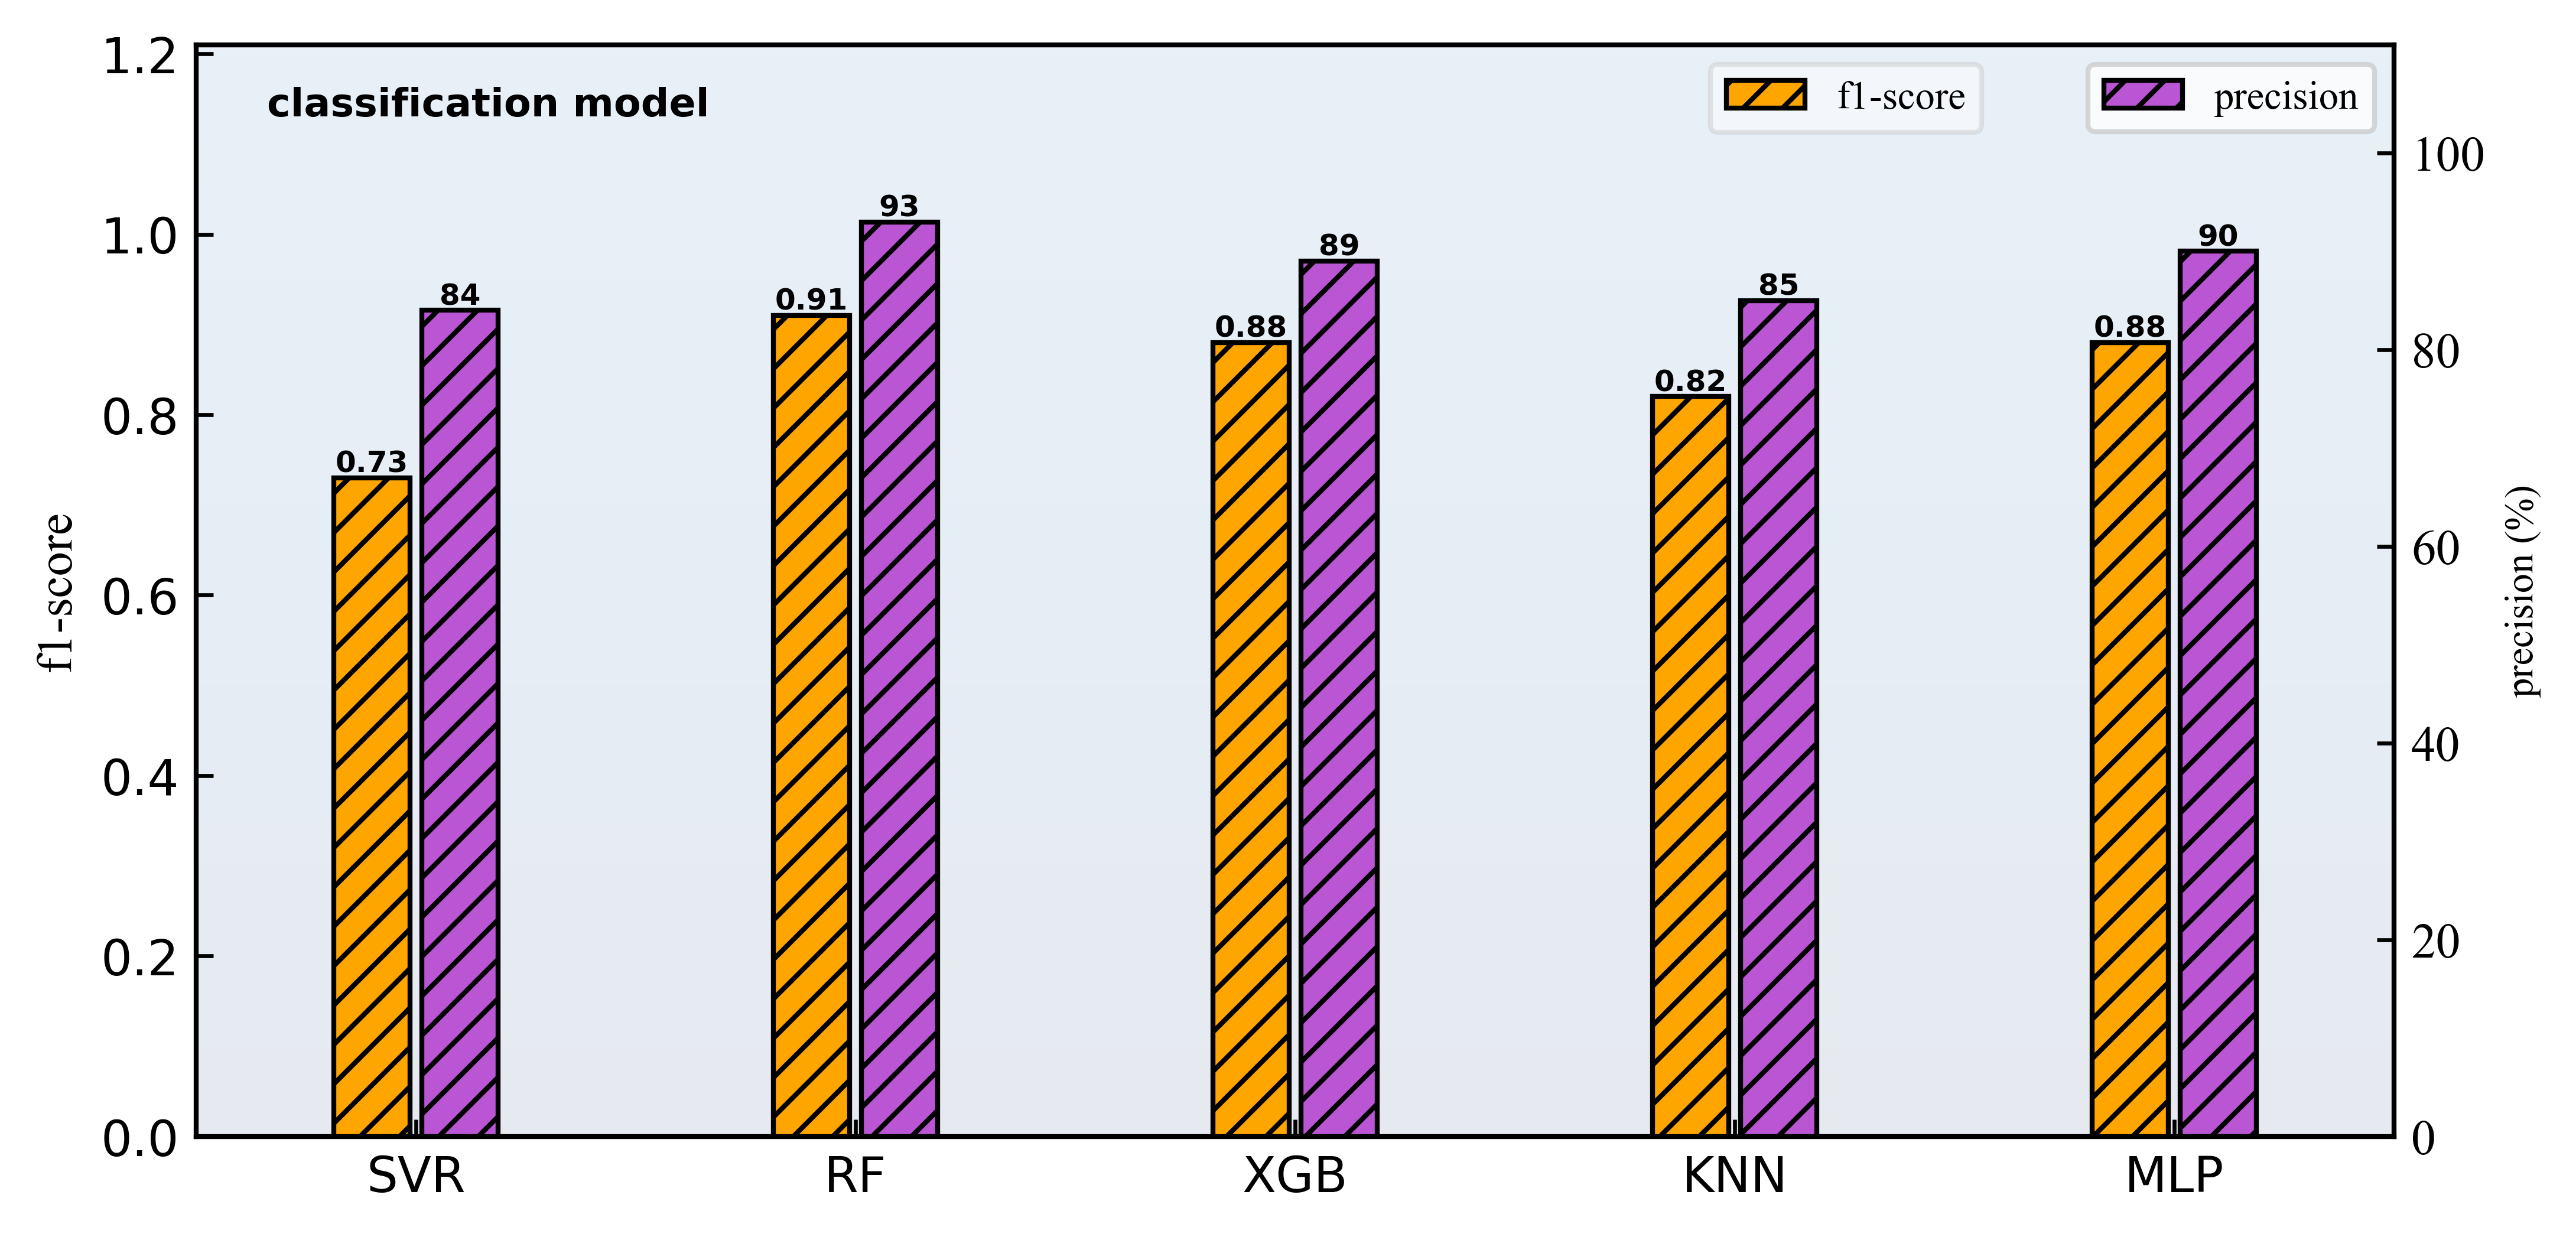

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerPatch

f1_1 = [0.73, 0.91, 0.88, 0.82, 0.88]  # R2
f1_2 = [84, 93, 89, 85, 90]  # MAPE
x = ['SVR', 'RF', 'XGB', 'KNN', 'MLP']
x_ticks = np.arange(len(x))
total_width, n = -0.6, -0.5
width = 0.2  # Reduce the width of the bars
xticks = x_ticks - (total_width - width) / 2  # Adjust the xticks

plt.figure(figsize=(8, 4), dpi=600)
ax = plt.axes()

# Create a custom colormap from white to light blue
cmap = plt.cm.get_cmap('Blues')  # Use a different colormap for lighter blue gradient

# Bar plots for f1_1 with diagonal hatching
f1_1_bar = ax.bar(xticks, f1_1, width=0.87 * width, label='f1-score', color="#FFA500", edgecolor='black',
                   linewidth=1, hatch='///', zorder=5)

# Secondary y-axis for f1_2 with diagonal hatching
ax2 = ax.twinx()
f1_2_bar = ax2.bar(xticks + width, f1_2, width=0.87 * width, label='precision', color="#BA55D3", edgecolor='black',
                   linewidth=1, hatch='///', zorder=5)

class HandlerBarLabel(HandlerPatch):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize):
        x = width / 2
        y = height / 2
        label = plt.Text(x, y, orig_handle,
                         fontsize=fontsize,
                         ha="center", va="center", fontweight='bold')
        return [label]

# Legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, handler_map={plt.Rectangle: HandlerBarLabel()}, fancybox=True,
          framealpha=0.5, prop={'family': 'Times New Roman', 'size': 8}, ncol=2,
          bbox_to_anchor=(0.68, 1), loc='upper left')
ax2.legend(prop={'family': 'Times New Roman', 'size': 8}, ncol=2)

plt.xticks(x_ticks, x, fontproperties='Times New Roman', fontsize=8, ha='center')  # Use original x-axis tick positions
plt.yticks(fontproperties='Times New Roman', fontsize=10)
ax.set_ylim(0, 1.21)
ax2.set_ylim(0, 111)  # Adjusted y-axis limit for ax2
ax.set_ylabel('f1-score', fontproperties='Times New Roman', fontsize=10)
ax2.set_ylabel("precision (%)", fontproperties='Times New Roman', fontsize=8)
plt.text(0.15, 0.83, 'classification model', fontsize=8, fontweight='bold', transform=plt.gcf().transFigure)  # Add text to the figure

# Customize spines
ax.spines['bottom'].set_linewidth('1.0')
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_linewidth('1.0')
ax.spines['top'].set_color('black')
ax.spines['right'].set_linewidth('1.0')
ax.spines['right'].set_color('black')
ax.spines['left'].set_linewidth('1.0')
ax.spines['left'].set_color('black')

# Set all tick lines inward
ax.tick_params(axis='both', direction='in')
ax2.tick_params(axis='both', direction='in')
# Create a meshgrid for gradient background
x_vals = np.linspace(0, 1, 100)
y_vals = np.linspace(0, 1, 100)
x_mesh, y_mesh = np.meshgrid(x_vals, y_vals)
background_data = y_mesh  # Use y values to create a gradient
ax.imshow(background_data, cmap=cmap, alpha=0.1, aspect='auto', extent=(0, len(x), 0, len(x)), zorder=1)
custom_xticks = [tick + width/0.4for tick in x_ticks]  # Shift the tick positions
plt.xticks(custom_xticks, x, fontproperties='Times New Roman', fontsize=8, ha='center')  # Use custom x-axis tick positions
# Add data labels on top of each bar
for i, (a, b) in enumerate(zip(f1_1_bar, f1_2_bar)):
    ax.text(a.get_x() + a.get_width() / 2, a.get_height(), str(f1_1[i]),
            ha='center', va='bottom', fontweight='bold', fontsize=6)
    ax2.text(b.get_x() + b.get_width() / 2, b.get_height(), str(f1_2[i]),
             ha='center', va='bottom', fontweight='bold', fontsize=6)

plt.show()

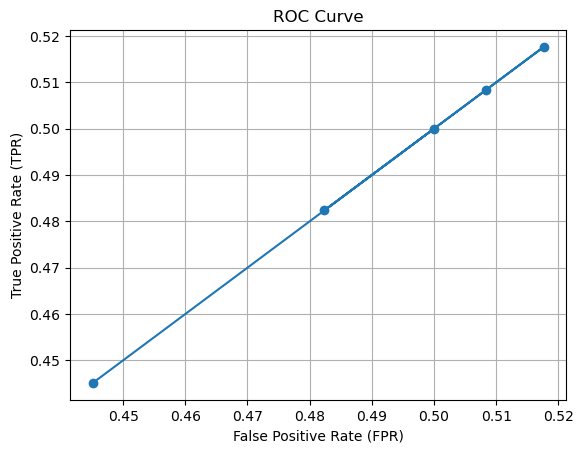

In [9]:
import matplotlib.pyplot as plt

# 提供的数据点
data_points = [(0.73, 0.91), (0.91, 0.88), (0.88, 0.82), (0.82, 0.88), (0.88, 0.88)]

# 计算真阳性率和假阳性率
tpr_values = [tp / (tp + fn) for tp, fn in data_points]
fpr_values = [fp / (fp + tn) for fp, tn in data_points]

# 绘制ROC曲线
plt.figure()
plt.plot(fpr_values, tpr_values, marker='o')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.grid(True)
plt.show()